# Module 11 Lab: Real-Time Object Tracking and Zone-Based Analytics

Welcome to an advanced topic in computer vision! In this lab, you will learn how to not just detect objects, but **track** them across video frames. You will also learn how to perform **zone-based analytics**, which involves analyzing object behavior within a specific region of the video.

**What you'll learn:**
- The difference between object detection and object tracking.
- How to use a pre-trained model to track objects in a video.
- How to define a 'zone' and count objects that enter it.

## Learning Objectives

By the end of this lab, you will be able to:

- **Differentiate** between object detection and object tracking.
- **Implement** an object tracking pipeline using the YOLO model.
- **Design** and implement a zone for analytics.
- **Analyze** the behavior of objects within a defined zone.

## 1. Setup and Installation

We will continue to use the `ultralytics` and `opencv-python` libraries.


In [13]:
%pip install ultralytics opencv-python requests

Now, let's import the necessary components.

In [14]:
from ultralytics import YOLO
import cv2
import requests
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

## 2. Understanding Object Tracking

### Object Detection vs. Object Tracking

- **Object Detection** is the process of identifying and locating objects in a single image or frame. It answers the question, 'What objects are in this frame and where are they?'
- **Object Tracking** is the process of identifying an object and following it across multiple frames. It answers the question, 'Where is this specific object going?' Tracking assigns a unique ID to each detected object, allowing it to be followed over time.

### Why is Tracking Useful?

Tracking is essential for many real-world applications, such as:
- **Retail Analytics:** Counting how many people enter a store and where they go.
- **Traffic Management:** Monitoring the flow of cars on a highway.
- **Security:** Following a person of interest through a building.

## Part 1: Coded Demonstration

In this part, we will track cars in a video and count how many of them enter a specific zone.

In [15]:
# 1. Load the YOLO model
model = YOLO('yolov8n.pt')

In [16]:
# 2. Download a video to analyze
# video_url = 'https://archive.org/download/highway_construction_2/highway_construction_2_512kb.mp4'
video_url = 'https://docs.google.com/uc?export=download&confirm=&id=1pz68D1Gsx80MoPg-_q-IbEdESEmyVLm-'
video_path = 'highway.mp4'
r = requests.get(video_url, stream=True)
with open(video_path, 'wb') as f:
    for chunk in r.iter_content(chunk_size=1024*1024):
        if chunk:
            f.write(chunk)




0: 384x640 3 cars, 1 truck, 162.4ms
Speed: 3.6ms preprocess, 162.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)
Object with ID 1 crossed the zone!

0: 384x640 3 cars, 1 truck, 327.1ms
Speed: 11.0ms preprocess, 327.1ms inference, 3.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 truck, 215.8ms
Speed: 5.7ms preprocess, 215.8ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 bus, 1 truck, 298.1ms
Speed: 8.7ms preprocess, 298.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 362.9ms
Speed: 12.7ms preprocess, 362.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 bus, 275.6ms
Speed: 5.4ms preprocess, 275.6ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 428.0ms
Speed: 12.4ms preprocess, 428.0ms inference, 3.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 

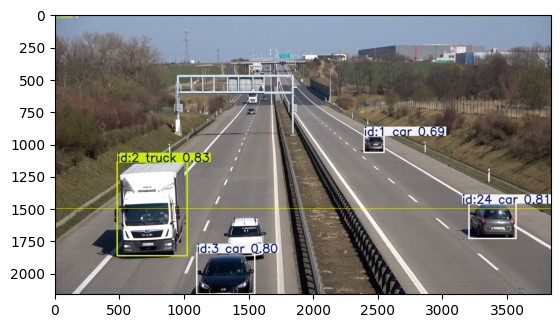


0: 384x640 3 cars, 2 trucks, 225.1ms
Speed: 8.7ms preprocess, 225.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 2 trucks, 225.1ms
Speed: 8.4ms preprocess, 225.1ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 2 trucks, 237.5ms
Speed: 7.6ms preprocess, 237.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 225.2ms
Speed: 7.2ms preprocess, 225.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 209.8ms
Speed: 7.8ms preprocess, 209.8ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 2 trucks, 203.9ms
Speed: 5.7ms preprocess, 203.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 truck, 147.3ms
Speed: 3.6ms preprocess, 147.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 2 trucks, 157.2ms
Speed: 7.7ms 

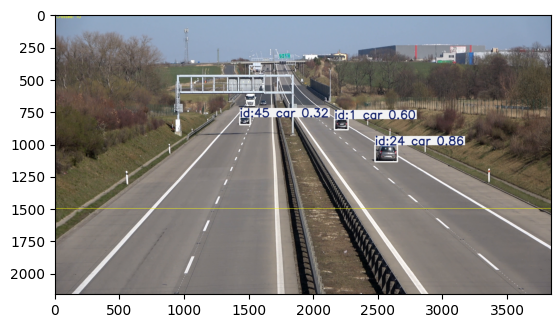


0: 384x640 3 cars, 151.9ms
Speed: 6.6ms preprocess, 151.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 135.8ms
Speed: 4.1ms preprocess, 135.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 155.7ms
Speed: 5.9ms preprocess, 155.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 144.9ms
Speed: 3.7ms preprocess, 144.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 140.8ms
Speed: 3.6ms preprocess, 140.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 140.3ms
Speed: 4.8ms preprocess, 140.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 149.9ms
Speed: 5.0ms preprocess, 149.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 144.5ms
Speed: 4.2ms preprocess, 144.5ms inference, 0.9ms postprocess per image at shape (1, 3, 38

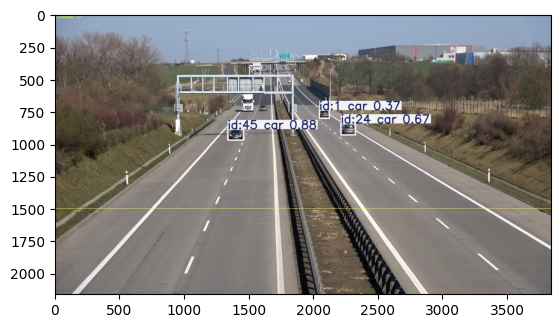


0: 384x640 2 cars, 172.6ms
Speed: 7.7ms preprocess, 172.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 155.1ms
Speed: 4.0ms preprocess, 155.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 131.8ms
Speed: 7.8ms preprocess, 131.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 144.2ms
Speed: 4.1ms preprocess, 144.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 148.0ms
Speed: 5.9ms preprocess, 148.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 163.6ms
Speed: 5.4ms preprocess, 163.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 147.0ms
Speed: 5.7ms preprocess, 147.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 142.7ms
Speed: 4.5ms preprocess, 142.7ms inference, 1.0ms postprocess per image at shape (1, 3, 38

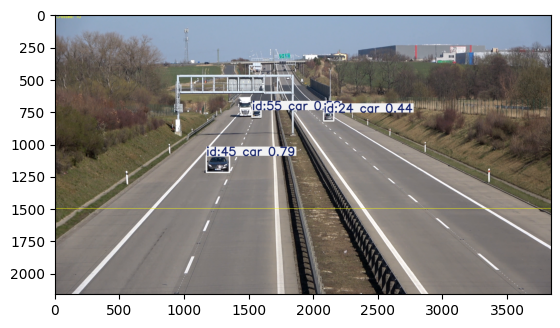


0: 384x640 3 cars, 172.4ms
Speed: 5.0ms preprocess, 172.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 151.4ms
Speed: 8.5ms preprocess, 151.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 177.8ms
Speed: 3.7ms preprocess, 177.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 153.0ms
Speed: 6.7ms preprocess, 153.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 145.1ms
Speed: 8.0ms preprocess, 145.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 139.7ms
Speed: 6.4ms preprocess, 139.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 160.2ms
Speed: 6.7ms preprocess, 160.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 157.6ms
Speed: 6.8ms preprocess, 157.6ms inference, 0.9ms postprocess per image at shape (1, 3, 38

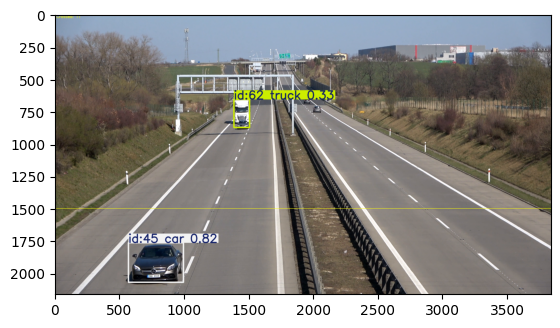


0: 384x640 1 car, 1 truck, 171.8ms
Speed: 4.0ms preprocess, 171.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 163.2ms
Speed: 6.7ms preprocess, 163.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 161.5ms
Speed: 8.1ms preprocess, 161.5ms inference, 2.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 155.1ms
Speed: 5.0ms preprocess, 155.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 train, 145.8ms
Speed: 6.7ms preprocess, 145.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 146.9ms
Speed: 6.6ms preprocess, 146.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 173.0ms
Speed: 5.6ms preprocess, 173.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 145.4ms
Speed: 8.1ms preprocess, 145.4ms inference, 1.2ms 

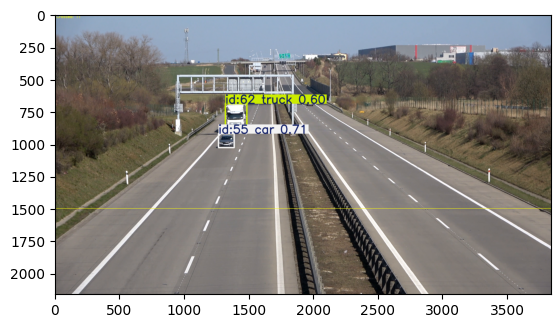


0: 384x640 1 car, 1 truck, 243.1ms
Speed: 6.8ms preprocess, 243.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 268.9ms
Speed: 5.0ms preprocess, 268.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 216.4ms
Speed: 7.7ms preprocess, 216.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 227.2ms
Speed: 5.6ms preprocess, 227.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 train, 281.9ms
Speed: 6.7ms preprocess, 281.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 255.1ms
Speed: 5.4ms preprocess, 255.1ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 230.7ms
Speed: 7.4ms preprocess, 230.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 193.7ms
Speed: 5.7ms preprocess, 193.7ms inferen

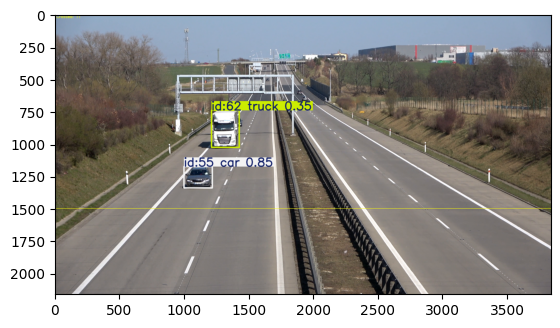


0: 384x640 1 car, 1 truck, 182.9ms
Speed: 5.8ms preprocess, 182.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 157.6ms
Speed: 5.4ms preprocess, 157.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 185.2ms
Speed: 6.7ms preprocess, 185.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 182.5ms
Speed: 6.0ms preprocess, 182.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 1 truck, 160.5ms
Speed: 7.9ms preprocess, 160.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 156.8ms
Speed: 4.7ms preprocess, 156.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 180.6ms
Speed: 8.7ms preprocess, 180.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 188.5ms
Speed: 5.8ms preproce

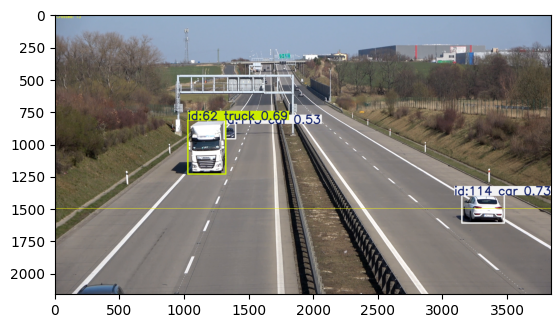


0: 384x640 2 cars, 1 truck, 215.9ms
Speed: 8.4ms preprocess, 215.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 181.9ms
Speed: 8.9ms preprocess, 181.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 169.0ms
Speed: 6.4ms preprocess, 169.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 192.0ms
Speed: 6.9ms preprocess, 192.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 202.3ms
Speed: 6.0ms preprocess, 202.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 179.3ms
Speed: 7.8ms preprocess, 179.3ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 200.0ms
Speed: 6.1ms preprocess, 200.0ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 173.2ms
Speed: 8.9ms prepr

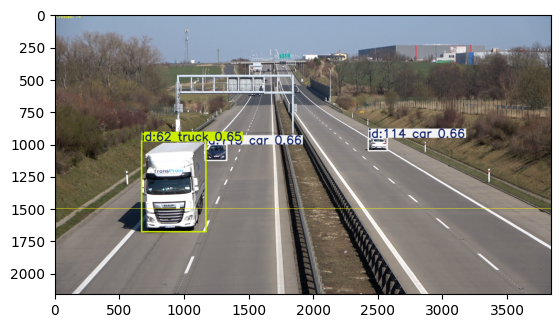


0: 384x640 2 cars, 1 truck, 245.1ms
Speed: 6.9ms preprocess, 245.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 192.9ms
Speed: 9.2ms preprocess, 192.9ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 173.3ms
Speed: 7.9ms preprocess, 173.3ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 183.9ms
Speed: 10.5ms preprocess, 183.9ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 257.4ms
Speed: 6.8ms preprocess, 257.4ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 256.4ms
Speed: 5.9ms preprocess, 256.4ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 270.1ms
Speed: 6.3ms preprocess, 270.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 207.9ms
Speed: 7.1ms prep

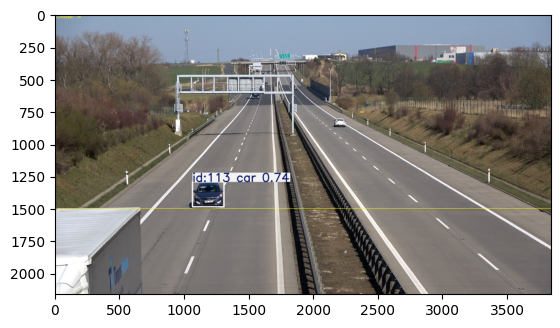


0: 384x640 1 car, 265.9ms
Speed: 7.2ms preprocess, 265.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
Object with ID 113 crossed the zone!

0: 384x640 2 cars, 183.1ms
Speed: 5.8ms preprocess, 183.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 199.8ms
Speed: 7.2ms preprocess, 199.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 188.3ms
Speed: 4.8ms preprocess, 188.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 191.8ms
Speed: 5.8ms preprocess, 191.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 174.0ms
Speed: 7.2ms preprocess, 174.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 220.1ms
Speed: 7.4ms preprocess, 220.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 211.1ms
Speed: 7.9ms preprocess, 211.1ms inference, 1.1ms postpro

In [17]:
# 3. Create the Tracking and Zone Analytics Agent

def tracking_agent(video_path):
    cap = cv2.VideoCapture(video_path)

    # Define the zone (a horizontal line in this case)
    zone_y = 1500

    # Store the IDs of objects that have crossed the zone
    crossed_objects = set()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Track objects in the frame
        results = model.track(frame, persist=True)

        # Get the annotated frame with bounding boxes and track IDs
        annotated_frame = results[0].plot()

        # Draw the zone line
        cv2.line(annotated_frame, (0, zone_y), (frame.shape[1], zone_y), (0, 255, 255), 2)

        # Check if any objects have crossed the zone
        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                # Check if the bottom of the box has crossed the line
                if box[3] > zone_y and track_id not in crossed_objects:
                    crossed_objects.add(track_id)
                    print(f'Object with ID {track_id} crossed the zone!')

        # Display the total count of crossed objects
        cv2.putText(annotated_frame, f'Crossed: {len(crossed_objects)}', (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        # Display the frame
        img = Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
        # To display in a notebook, we can show a few frames
        if cap.get(cv2.CAP_PROP_POS_FRAMES) % 50 == 0:
            plt.imshow(img)
            plt.show()

    cap.release()

# Run the agent
tracking_agent(video_path)

## Part 2: Student Challenge

Your challenge is to modify the agent to count objects in a different zone. Instead of a horizontal line, you will define a **rectangular zone** and count how many objects are **inside** it in each frame.

**Your Task:**
1.  Define a rectangular zone (e.g., `zone = [x1, y1, x2, y2]`).
2.  Modify the agent to count how many objects are inside the zone in each frame.
3.  Display the count on the frame.


0: 384x640 5 cars, 1 truck, 189.7ms
Speed: 4.1ms preprocess, 189.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 196.3ms
Speed: 9.5ms preprocess, 196.3ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 261.1ms
Speed: 10.6ms preprocess, 261.1ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 bus, 1 truck, 146.9ms
Speed: 4.1ms preprocess, 146.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 134.4ms
Speed: 3.9ms preprocess, 134.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 bus, 135.8ms
Speed: 4.4ms preprocess, 135.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 173.0ms
Speed: 4.1ms preprocess, 173.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 1 truck, 141.5ms
Speed: 3.6ms

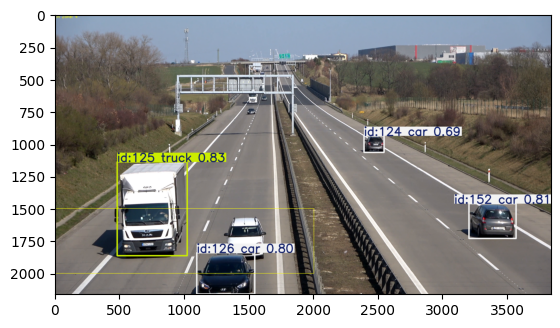


0: 384x640 3 cars, 2 trucks, 158.6ms
Speed: 10.5ms preprocess, 158.6ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 2 trucks, 135.4ms
Speed: 4.8ms preprocess, 135.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 2 trucks, 144.1ms
Speed: 8.2ms preprocess, 144.1ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 138.6ms
Speed: 4.1ms preprocess, 138.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 cars, 1 truck, 166.6ms
Speed: 6.8ms preprocess, 166.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 2 trucks, 139.3ms
Speed: 4.9ms preprocess, 139.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 1 truck, 148.7ms
Speed: 7.4ms preprocess, 148.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 4 cars, 2 trucks, 135.2ms
Speed: 4.5ms

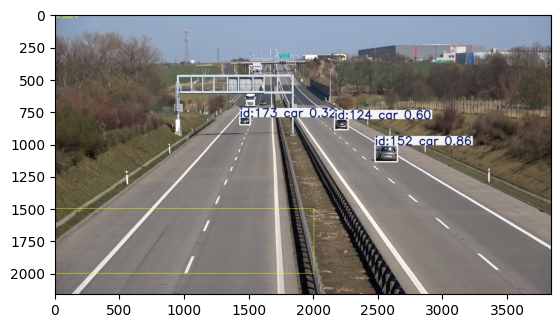


0: 384x640 3 cars, 150.3ms
Speed: 8.1ms preprocess, 150.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 150.9ms
Speed: 6.7ms preprocess, 150.9ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 157.0ms
Speed: 5.9ms preprocess, 157.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 143.3ms
Speed: 9.8ms preprocess, 143.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 137.0ms
Speed: 10.0ms preprocess, 137.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 156.7ms
Speed: 6.8ms preprocess, 156.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 151.4ms
Speed: 5.8ms preprocess, 151.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 143.2ms
Speed: 4.7ms preprocess, 143.2ms inference, 0.9ms postprocess per image at shape (1, 3, 3

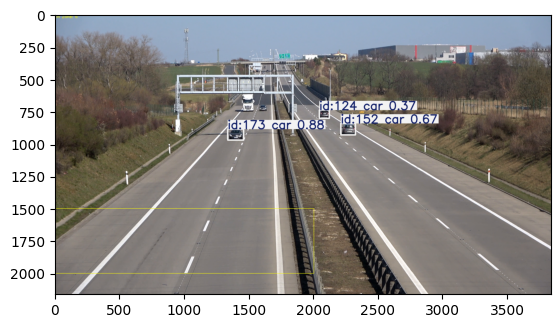


0: 384x640 2 cars, 187.3ms
Speed: 6.9ms preprocess, 187.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 168.1ms
Speed: 4.8ms preprocess, 168.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 143.1ms
Speed: 9.2ms preprocess, 143.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 153.0ms
Speed: 3.6ms preprocess, 153.0ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 152.6ms
Speed: 5.9ms preprocess, 152.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 155.1ms
Speed: 8.4ms preprocess, 155.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 140.1ms
Speed: 7.8ms preprocess, 140.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 135.6ms
Speed: 6.7ms preprocess, 135.6ms inference, 0.9ms postprocess per image at shape (1, 3, 38

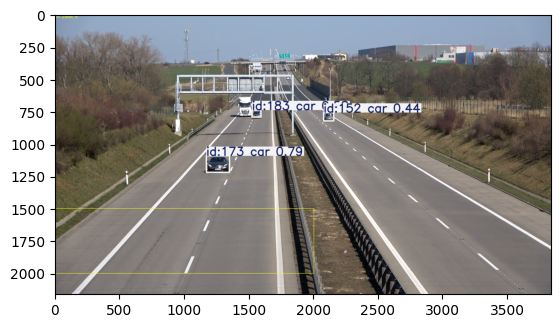


0: 384x640 3 cars, 151.0ms
Speed: 8.1ms preprocess, 151.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 149.3ms
Speed: 5.0ms preprocess, 149.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 157.7ms
Speed: 6.9ms preprocess, 157.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 157.4ms
Speed: 3.8ms preprocess, 157.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 cars, 164.2ms
Speed: 7.9ms preprocess, 164.2ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 148.7ms
Speed: 7.8ms preprocess, 148.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 173.2ms
Speed: 4.3ms preprocess, 173.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 155.0ms
Speed: 6.4ms preprocess, 155.0ms inference, 1.0ms postprocess per image at shape (1, 3, 38

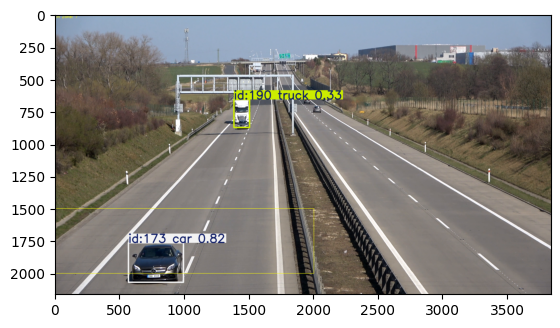


0: 384x640 1 car, 1 truck, 165.3ms
Speed: 6.7ms preprocess, 165.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 154.6ms
Speed: 7.8ms preprocess, 154.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 193.9ms
Speed: 5.8ms preprocess, 193.9ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 168.4ms
Speed: 8.2ms preprocess, 168.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 train, 149.5ms
Speed: 8.2ms preprocess, 149.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 150.4ms
Speed: 10.0ms preprocess, 150.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 192.9ms
Speed: 7.8ms preprocess, 192.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 172.4ms
Speed: 3.8ms preprocess, 172.4ms inference, 0.9ms

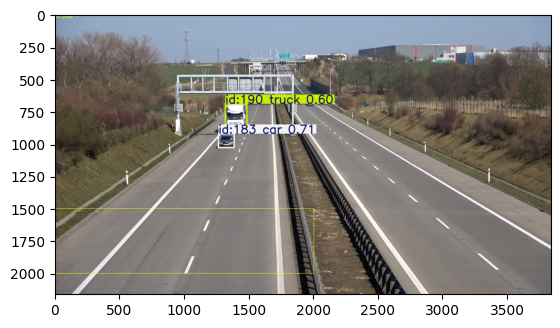


0: 384x640 1 car, 1 truck, 186.2ms
Speed: 5.9ms preprocess, 186.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 162.9ms
Speed: 8.0ms preprocess, 162.9ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 177.9ms
Speed: 6.4ms preprocess, 177.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 174.1ms
Speed: 5.6ms preprocess, 174.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 train, 272.3ms
Speed: 7.3ms preprocess, 272.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 266.0ms
Speed: 3.9ms preprocess, 266.0ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 252.2ms
Speed: 6.6ms preprocess, 252.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 230.5ms
Speed: 6.2ms preprocess, 230.5ms inferen

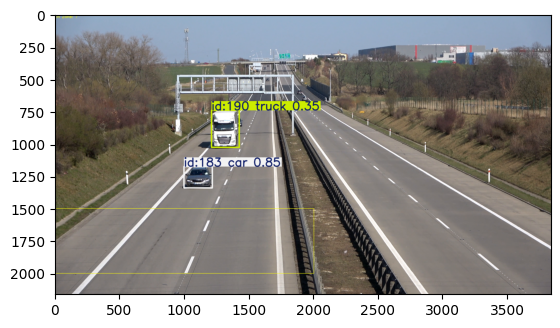


0: 384x640 1 car, 1 truck, 229.1ms
Speed: 7.7ms preprocess, 229.1ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 213.4ms
Speed: 9.7ms preprocess, 213.4ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 261.9ms
Speed: 7.3ms preprocess, 261.9ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 249.8ms
Speed: 4.1ms preprocess, 249.8ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 1 truck, 181.0ms
Speed: 6.8ms preprocess, 181.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 173.4ms
Speed: 5.7ms preprocess, 173.4ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 truck, 187.6ms
Speed: 7.7ms preprocess, 187.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 1 bus, 169.0ms
Speed: 8.9ms preproce

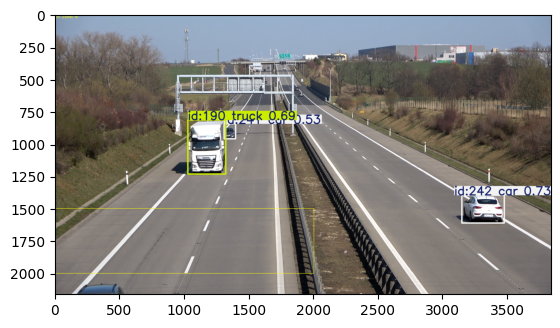


0: 384x640 2 cars, 1 truck, 205.7ms
Speed: 7.8ms preprocess, 205.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 187.5ms
Speed: 4.1ms preprocess, 187.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 168.1ms
Speed: 8.8ms preprocess, 168.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 190.7ms
Speed: 5.5ms preprocess, 190.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 199.2ms
Speed: 4.6ms preprocess, 199.2ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 170.3ms
Speed: 6.2ms preprocess, 170.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 168.7ms
Speed: 8.3ms preprocess, 168.7ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 176.3ms
Speed: 4.8ms prepr

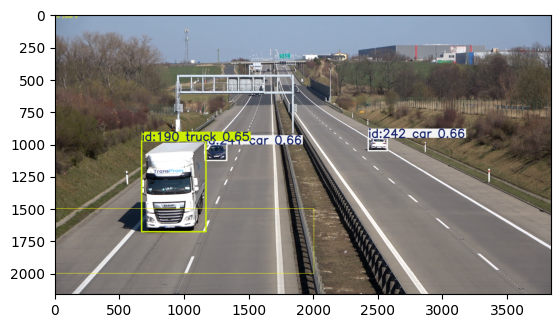


0: 384x640 2 cars, 1 truck, 213.4ms
Speed: 5.5ms preprocess, 213.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 206.4ms
Speed: 5.6ms preprocess, 206.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 175.6ms
Speed: 5.9ms preprocess, 175.6ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 182.0ms
Speed: 7.5ms preprocess, 182.0ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 198.5ms
Speed: 7.4ms preprocess, 198.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 182.5ms
Speed: 5.6ms preprocess, 182.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 193.0ms
Speed: 5.9ms preprocess, 193.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 1 truck, 184.8ms
Speed: 6.9ms prepr

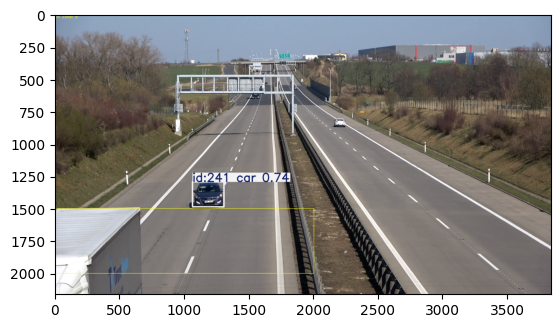


0: 384x640 1 car, 186.4ms
Speed: 5.6ms preprocess, 186.4ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 198.5ms
Speed: 5.7ms preprocess, 198.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 203.2ms
Speed: 3.9ms preprocess, 203.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 208.3ms
Speed: 7.6ms preprocess, 208.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 182.2ms
Speed: 9.1ms preprocess, 182.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 179.8ms
Speed: 9.4ms preprocess, 179.8ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 cars, 224.1ms
Speed: 8.9ms preprocess, 224.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 car, 191.2ms
Speed: 7.8ms preprocess, 191.2ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 6

In [18]:
# --- ENTER YOUR CODE HERE ---

# 1. Define your rectangular zone
# zone = [x1, y1, x2, y2]
zone_box = [1500, 0, 2000, 2000]
# 2. Create your new agent function
def zone_counting_agent(video_path):
    # ...
    cap = cv2.VideoCapture(video_path)

    # Define the box zone: (x_min, y_min, x_max, y_max)
    zone_box = [0, 1500, 2000, 2000]

    # Store the IDs of objects that have entered the zone
    crossed_objects = set()

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        results = model.track(frame, persist=True)
        annotated_frame = results[0].plot()

        # Draw the zone box
        cv2.rectangle(annotated_frame, (zone_box[0], zone_box[1]), (zone_box[2], zone_box[3]), (0, 255, 255), 2)

        if results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu()
            track_ids = results[0].boxes.id.int().cpu().tolist()

            for box, track_id in zip(boxes, track_ids):
                # Calculate the center point of the object's bounding box
                obj_center_x = (box[0] + box[2]) / 2
                obj_center_y = (box[1] + box[3]) / 2

                # Check if the center point is inside the zone box
                is_inside = (zone_box[0] < obj_center_x < zone_box[2]) and \
                            (zone_box[1] < obj_center_y < zone_box[3])

                if is_inside and track_id not in crossed_objects:
                    crossed_objects.add(track_id)
                    print(f'Object with ID {track_id} entered the box!')

        cv2.putText(annotated_frame, f'In Zone: {len(crossed_objects)}', (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)

        # Display logic (Notebook compatible)
        if cap.get(cv2.CAP_PROP_POS_FRAMES) % 50 == 0:
            img = Image.fromarray(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
            plt.imshow(img)
            plt.show()
    cap.release()

# 3. Run your new agent

zone_counting_agent(video_path)

## Reflective Questions

Please answer the following questions in a new Markdown cell below.

1.  What is the key difference between `model.predict()` and `model.track()` in the YOLO library?
2.  In our coded demonstration, we only counted an object once when it crossed the line. How did we achieve this? Why is it important?
3.  Describe a real-world application for zone-based analytics. What kind of zone would you define, and what would you measure?
4.  What are some of the challenges in object tracking? (e.g., what happens if an object is hidden for a few frames?)

1. Use model.perdict() for single images, or if you only need to know how many objects are in a single frame at a time. Use model.track() for video streams where you need to follow movement, count unique visitors, or analyze behavior over time.
2. We used a Python set to store the unique IDs of objects as they crossed the line. This is crucial because it prevents a single object from being counted multiple times—otherwise, the system would record a "new" count for every single frame that the object remains in the zone.
3. One real world application of this could be for optimizing staffing at a giant retail store. Setting zones at the enterances and exits, they can monitor if the store is getting crowded and if so open up more cash registers to get people moving.
4. The biggest challenge is occlusion, where an object hidden behind an obstacle may be assigned a brand-new ID upon reappearing, leading to duplicate counts. Additionally, tracking can suffer from ID switching when objects overlap, or flickering due to poor lighting, both of which compromise the accuracy of your data.


## Submission Instructions

1.  Complete the **Student Challenge** section with your modified agent.
2.  Answer the **Reflective Questions** in a new Markdown cell.
3.  Save your completed notebook (`.ipynb` file) and submit it.